In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

### 1_first workflow_bmi_calc

In [7]:
# 2 input quantity height and weight -> cal bmi -> output
# so here height and weitght are stategraph

In [18]:
# define state
class bmistate(TypedDict):
    weight_kg : float
    height_me : float
    bmi       : float
    category  : str

In [11]:
def cal_bmi(state: bmistate) ->bmistate :
    weight = state['weight_kg']
    height =state['height_me']
    
    bmi =weight /(height**2)
    
    state['bmi'] = round(bmi,2)
    
    return state

In [21]:
def label_bmi(state : bmistate) -> bmistate:
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['category'] = "underweight"
    elif 18.5 <= bmi <25:
        state['category'] = "normal"
    elif 25 <= bmi < 30:
        state['category'] = "overweight"
    else:
        state['category'] = "obase"  
        
    return state     
                

In [22]:
# define stategraph
graph = StateGraph(bmistate)

# add node to your graph
graph.add_node("cal_bmi",cal_bmi)
graph.add_node('label_bmi',label_bmi)

# add edge to your graph
graph.add_edge(START , 'cal_bmi')
graph.add_edge('cal_bmi','label_bmi')
graph.add_edge("label_bmi" , END)

# copmpile to the graph
workflow = graph.compile()




In [23]:
# execute the graph
inital_state = {'weight_kg' : 60 ,'height_me' : 2.01}

final_state = workflow.invoke(inital_state)

print(final_state)

{'weight_kg': 60, 'height_me': 2.01, 'bmi': 14.85, 'category': 'underweight'}


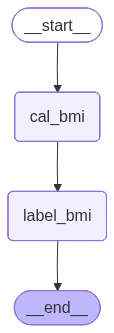

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())